1. Import Libraries

In [26]:
import pandas as pd
import numpy as np
import pickle

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score

2. Load Data

In [27]:
df = pd.read_csv("../data/processed_data.csv")

target_column = "productivity_score"

X = df[
[
'study_hours_per_day',
'focus_score',
'sleep_hours',
'attendance_percentage',
'stress_level',
'phone_usage_hours',
'social_media_hours'
]]

y = df[target_column]

3. Load Model & Scaler

In [28]:
with open("../models/linear/model.pkl", "rb") as f:
    model = pickle.load(f)

with open("../models/linear/scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

4. Train-Test Split

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

5. Scale Data

In [30]:
X_test_scaled = scaler.transform(X_test)

6. Predictions

In [31]:
y_pred = model.predict(X_test_scaled)

7. Evaluation Metrics

In [32]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
a = accuracy_score(y_test.round(), y_pred.round())



print("MSE:", mse)
print("MAE:", mae)
print("R2 Score:", r2)
print("Accuracy:", a)

MSE: 0.0005631674266747375
MAE: 0.006818189388072886
R2 Score: 0.9999978133106797
Accuracy: 0.993


8. Graph 1: Actual vs Predicted

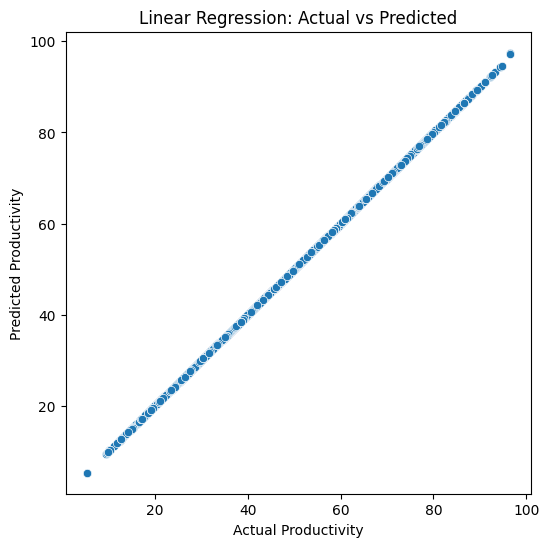

In [33]:
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Productivity")
plt.ylabel("Predicted Productivity")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

9. Graph 2: Residual Distribution

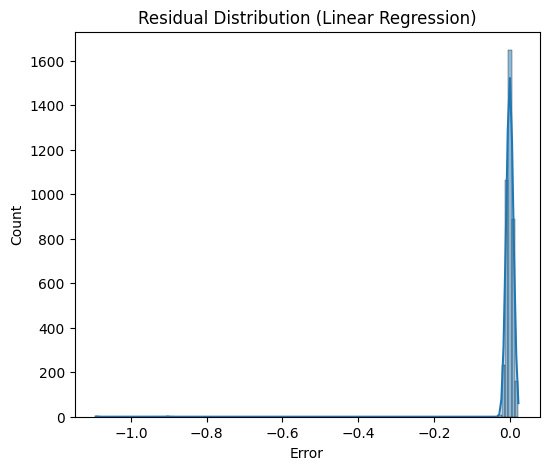

In [34]:
residuals = y_test - y_pred

plt.figure(figsize=(6,5))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution (Linear Regression)")
plt.xlabel("Error")
plt.show()

10. Graph 3: Residual vs Predicted

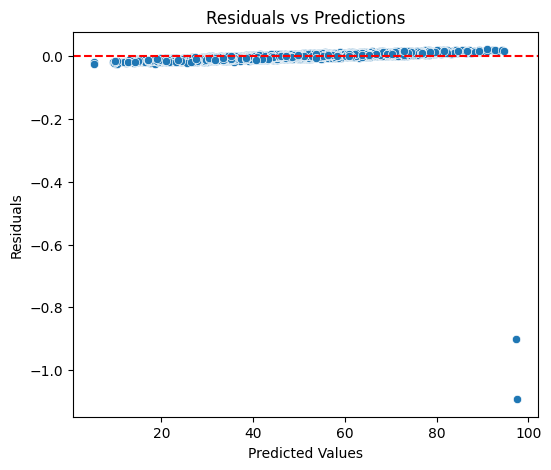

In [35]:
plt.figure(figsize=(6,5))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predictions")
plt.show()